<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec03_pca_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA (Principal Component Analysis) 실습

이 실습에서는 PCA의 원리를 이해하고 직접 구현합니다:
1. sklearn을 이용한 PCA
2. PCA를 처음부터 직접 구현 (from scratch)
3. 이미지에 PCA 적용

**PCA 단계:**
- Step 1: Centering (평균 빼기)
- Step 2: Covariance Matrix (공분산 행렬)
- Step 3: Eigen Values & Vectors (고유값/고유벡터)
- Step 4: Principal Component (주성분 선택)
- Step 5: Reconstruction (원본 데이터 복원)

**총점: 100점**

**학번:**  2023042028\
**이름:** 권택주

---
## Part 1: 데이터셋 준비 (10점)

키(height)와 몸무게(weight) 데이터를 사용하여 2D 데이터셋을 준비합니다.

---

### 문제 1-1. 데이터셋 생성 및 시각화 [10점]

x(키)와 y(몸무게) 배열을 2D 데이터로 결합합니다.

**문제:** `np.column_stack`을 사용하여 x와 y를 결합하세요.

**힌트:** `data = np.column_stack((x, y))`

**예상 결과:** 100개의 2D 데이터 포인트가 산점도로 표시됨

데이터 크기: (100, 2)


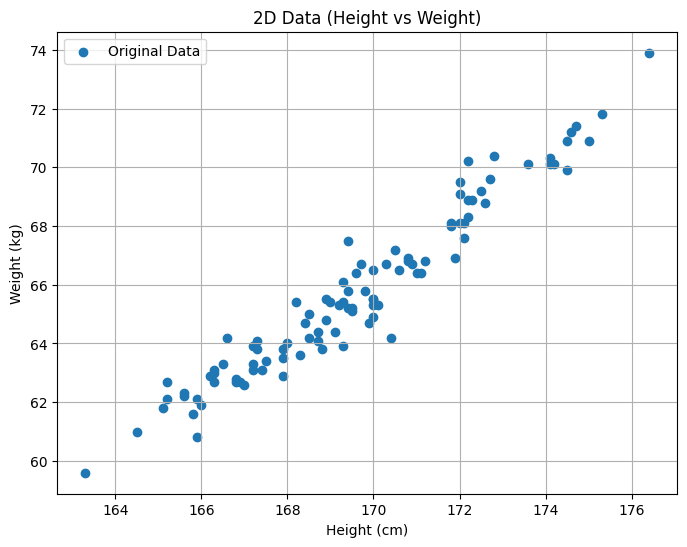

In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt

x = np.array([168.9, 165.1, 168.9, 176.4, 166.6, 171.2, 172.8, 172.0, 170.4, 171.9,
              174.1, 169.9, 168.7, 167.9, 169.0, 170.3, 174.5, 172.2, 165.9, 167.3,
              174.2, 170.5, 168.2, 169.3, 165.2, 163.3, 172.7, 175.3, 172.6, 166.2,
              168.0, 169.8, 169.6, 168.5, 168.3, 165.8, 173.6, 169.4, 167.2, 167.0,
              168.8, 168.5, 165.2, 167.2, 175.0, 174.5, 164.5, 172.0, 165.6, 169.1,
              170.6, 167.4, 170.0, 170.8, 166.8, 170.0, 171.8, 166.3, 172.3, 172.2,
              169.7, 167.9, 172.5, 174.7, 166.3, 167.3, 169.4, 172.1, 170.8, 168.4,
              167.2, 172.0, 169.2, 167.9, 170.0, 169.3, 166.5, 171.1, 165.9, 172.2,
              165.6, 172.1, 169.4, 171.8, 166.9, 168.7, 166.0, 170.0, 169.3, 174.6,
              169.5, 171.0, 166.3, 169.5, 174.1, 170.0, 167.5, 166.8, 170.9, 170.1])

y = np.array([64.8, 61.8, 65.5, 73.9, 64.2, 66.8, 70.4, 69.5, 64.2, 66.9,
              70.3, 64.7, 64.4, 63.8, 65.4, 66.7, 70.9, 70.2, 60.8, 64.1,
              70.1, 67.2, 65.4, 63.9, 62.1, 59.6, 69.6, 71.8, 68.8, 62.9,
              64.0, 65.8, 66.4, 65.0, 63.6, 61.6, 70.1, 67.5, 63.9, 62.6,
              63.8, 64.2, 62.7, 63.3, 70.9, 69.9, 61.0, 69.1, 62.2, 64.4,
              66.5, 63.1, 65.5, 66.9, 62.8, 65.5, 68.1, 63.1, 68.9, 68.3,
              66.7, 62.9, 69.2, 71.4, 62.7, 63.8, 65.2, 68.1, 66.8, 64.7,
              63.1, 68.1, 65.3, 63.5, 64.9, 65.4, 63.3, 66.4, 62.1, 68.9,
              62.3, 67.6, 65.8, 68.0, 62.7, 64.1, 61.9, 65.3, 66.1, 71.2,
              65.1, 66.4, 63.0, 65.2, 70.1, 66.5, 63.4, 62.7, 66.7, 65.3])

# IMPLEMENT HERE: x와 y를 column_stack으로 결합
data = np.column_stack((x, y))

print(f"데이터 크기: {data.shape}")

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], label='Original Data')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('2D Data (Height vs Weight)')
plt.grid(True)
plt.legend()
plt.show()

---
## Part 2: sklearn PCA (15점)

sklearn의 PCA를 사용하여 주성분 분석을 수행합니다.

---

### 문제 2-1. sklearn PCA 적용 [15점]

sklearn의 PCA를 사용하여 2개의 주성분을 추출합니다.

**문제:** PCA 객체를 생성하고, fit, transform을 수행하세요.

**힌트:**
```python
pca = PCA(n_components=2)
pca.fit(data)
data_pca = pca.transform(data)
```

**예상 결과:**
- PC1이 대부분의 분산을 설명 (약 97%)
- 주성분 방향이 화살표로 표시됨

PCA components (principal axes):
[[ 0.69251136  0.72140697]
 [ 0.72140697 -0.69251136]]

Explained variance ratio:
[0.98354664 0.01645336]


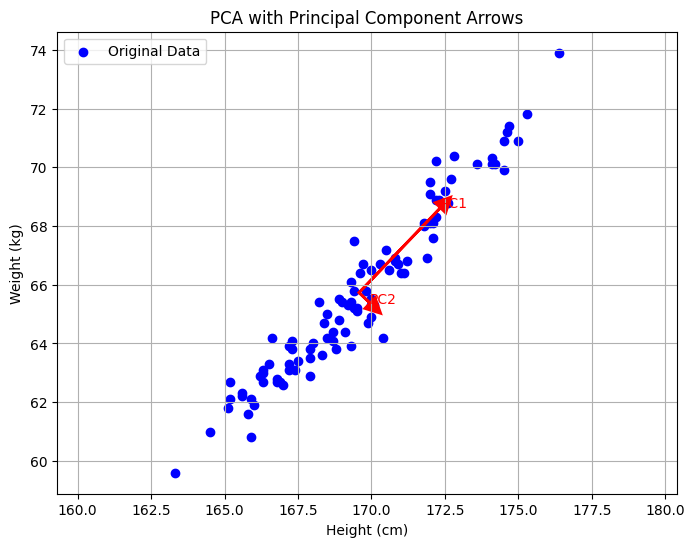

In [2]:
#@title { vertical-output: true}
from sklearn.decomposition import PCA

# IMPLEMENT HERE: PCA 생성, fit, transform
pca = PCA(n_components=2)
pca.fit(data)
data_pca = pca.transform(data)

print("PCA components (principal axes):")
print(pca.components_)
print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

# Draw the graph with principal component arrows
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], label='Original Data', color='blue')

mean = np.mean(data, axis=0)
for i in range(2):
    component = pca.components_[i]
    variance = pca.explained_variance_[i]
    vector = component * np.sqrt(variance)
    plt.arrow(mean[0], mean[1], vector[0], vector[1],
              head_width=0.5, head_length=0.5, fc='red', ec='red', linewidth=2)
    plt.text(mean[0] + vector[0], mean[1] + vector[1], f'PC{i+1}', fontsize=10, color='red')

plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('PCA with Principal Component Arrows')
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

---
## Part 3: PCA from Scratch (55점)

PCA를 처음부터 직접 구현합니다.

---

### 문제 3-1. Step 1 - Centering [10점]

데이터의 평균을 빼서 중심화(centering)합니다.

**공식:** $X_{centered} = X - \mu$

**문제:** 데이터를 중심화하세요.

**힌트:**
```python
mean_data = np.mean(data, axis=0)
cdata = data - mean_data
```

**예상 결과:** 데이터가 원점 근처로 이동됨

원본 데이터 평균: [169.578  65.733]
중심화 데이터 평균: [ 5.45696821e-14 -3.76587650e-15]


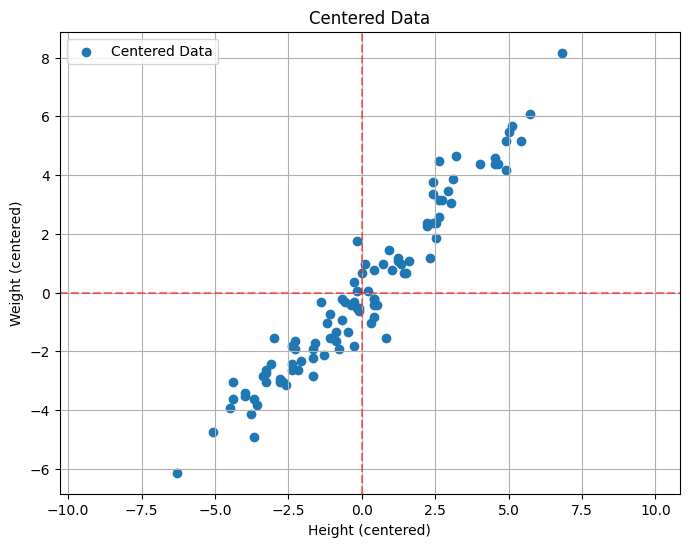

In [3]:
#@title { vertical-output: true}
data = np.column_stack((x, y))

# IMPLEMENT HERE: 평균 계산 및 중심화
mean_data = np.mean(data, axis=0)
cdata = data - mean_data

print(f"원본 데이터 평균: {np.mean(data, axis=0)}")
print(f"중심화 데이터 평균: {np.mean(cdata, axis=0)}")

# Plot centered data
plt.figure(figsize=(8, 6))
plt.scatter(cdata[:, 0], cdata[:, 1], label='Centered Data')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('Height (centered)')
plt.ylabel('Weight (centered)')
plt.title('Centered Data')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

### 문제 3-2. Step 2 - Covariance Matrix [10점]

공분산 행렬을 직접 계산합니다.

**공식:** $Cov = \frac{1}{n-1} X^T X$

**문제:** 공분산 행렬을 계산하세요.

**힌트:** `cov = 1 / (n-1) * cdata.T @ cdata`

**예상 결과:** 2x2 공분산 행렬

In [6]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 공분산 행렬 계산
cov = 1 / (cdata.shape[0]-1) * cdata.T @ cdata

# np.cov로 검증
cov_numpy = np.cov(cdata, rowvar=False)

print("직접 계산한 공분산 행렬:")
print(cov)
print("\nnp.cov로 계산한 공분산 행렬:")
print(cov_numpy)

직접 계산한 공분산 행렬:
[[7.81688485 7.86406667]
 [7.86406667 8.46001111]]

np.cov로 계산한 공분산 행렬:
[[7.81688485 7.86406667]
 [7.86406667 8.46001111]]


### 문제 3-3. Step 3 - Eigen Values & Vectors [10점]

공분산 행렬의 고유값과 고유벡터를 계산합니다.

**문제:** `np.linalg.eig`를 사용하여 고유값과 고유벡터를 계산하세요.

**힌트:** `eig_values, eig_vectors = np.linalg.eig(cov)`

**예상 결과:** 2개의 고유값과 2x2 고유벡터 행렬

In [7]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 고유값, 고유벡터 계산
eig_values, eig_vectors = np.linalg.eig(cov)

print("고유값 (Eigenvalues):")
print(eig_values)
print("\n고유벡터 (Eigenvectors):")
print(eig_vectors)
print(f"\n가장 큰 고유값의 인덱스: {np.argmax(eig_values)}")

고유값 (Eigenvalues):
[ 0.26780967 16.00908629]

고유벡터 (Eigenvectors):
[[-0.72140697 -0.69251136]
 [ 0.69251136 -0.72140697]]

가장 큰 고유값의 인덱스: 1


### 문제 3-4. Step 4 - Principal Component [10점]

가장 큰 고유값에 해당하는 고유벡터(주성분)를 선택하고 데이터를 투영합니다.

**문제:**
1. 가장 큰 고유값에 해당하는 고유벡터를 pc1으로 선택
2. 데이터를 pc1에 투영

**힌트:**
```python
pc1 = eig_vectors[:, np.argmax(eig_values)].reshape(2, 1)
proj_data = cdata @ pc1
```

**예상 결과:** 1차원으로 투영된 데이터

In [8]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 주성분 선택 및 투영
pc1 = eig_vectors[:, np.argmax(eig_values)].reshape(2, 1)
proj_data = cdata @ pc1

print(f"주성분 (PC1): {pc1.flatten()}")
print(f"투영된 데이터 크기: {proj_data.shape}")
print(f"투영된 데이터 샘플 (처음 5개): {proj_data[:5].flatten()}")

주성분 (PC1): [-0.69251136 -0.72140697]
투영된 데이터 크기: (100, 1)
투영된 데이터 샘플 (처음 5개): [  1.14259541   5.93835948   0.63761052 -10.61604322   3.16821571]


### 문제 3-5. Step 5 - Reconstruction [15점]

투영된 데이터를 원래 공간으로 복원합니다.

**공식:** $X_{reconstructed} = (X \cdot PC1) \cdot PC1^T + \mu$

**문제:** 투영된 데이터를 복원하세요.

**힌트:** `recon = proj_data @ pc1.T + mean_data`

**예상 결과:** 복원된 데이터가 주성분 축 위에 정렬됨

복원된 데이터 크기: (100, 2)


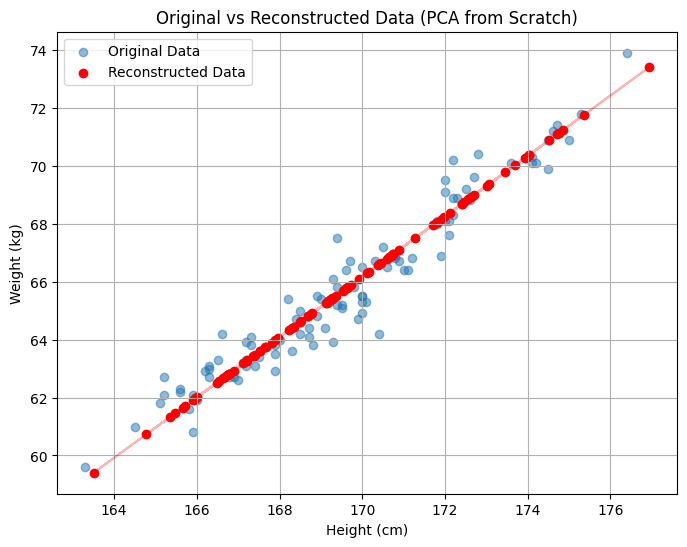

In [9]:
#@title { vertical-output: true}
# IMPLEMENT HERE: 데이터 복원
recon = proj_data @ pc1.T + mean_data

print(f"복원된 데이터 크기: {recon.shape}")

# Plot the original data and its projection
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label='Original Data')
plt.scatter(recon[:, 0], recon[:, 1], label='Reconstructed Data', color='red')
plt.plot(recon[:, 0], recon[:, 1], 'r-', alpha=0.3)
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Original vs Reconstructed Data (PCA from Scratch)')
plt.grid(True)
plt.legend()
plt.show()

---
## Part 4: PCA for Image (20점)

PCA를 이미지에 적용하여 차원 축소 및 복원을 수행합니다.

---

### 문제 4-1. 이미지 로드 함수

이미지를 로드하고 특성 벡터로 변환하는 함수입니다. (제공됨)

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
#@title { vertical-output: true}
from PIL import Image

def LoadImage(path):
    image = Image.open(path)
    img = np.array(image)
    img = img[:, :, 0]

    im_width, im_height = image.size
    pixel_block = 10
    features = []

    for i in range(0, im_height, pixel_block):
        for j in range(0, im_width, pixel_block):
            end_row = i + pixel_block
            end_column = j + pixel_block
            features.append(img[end_row - pixel_block:end_row, end_column - pixel_block:end_column])

    features = np.array(features)
    features = features.reshape(features.shape[0], features.shape[1] * features.shape[2])
    return features, img

# 이미지 로드 테스트
features, image = LoadImage("/content/drive/MyDrive/Colab Notebooks/palomino_horse.png")
print(f"특성 벡터 크기: {features.shape}")

특성 벡터 크기: (400, 100)


### 문제 4-2. 이미지 PCA 구현 [20점]

이미지에 PCA를 적용하여 다양한 주성분 개수로 복원합니다.

**문제:** PCA 함수 내부를 완성하세요.

**구현할 부분:**
1. Step 1: Centering (X = features - mean)
2. Step 2: Covariance matrix from scratch
3. Step 3: Eigen values/vectors
4. Step 4: Sort by eigenvalue & projection (Z = X @ eig_vectors)
5. Reconstruction: T, E, R 계산

**예상 결과:** 주성분 개수에 따른 이미지 복원 결과 (1, 5, 10, 20, 100개)

Features shape: (400, 100)
X shape: (400, 100)


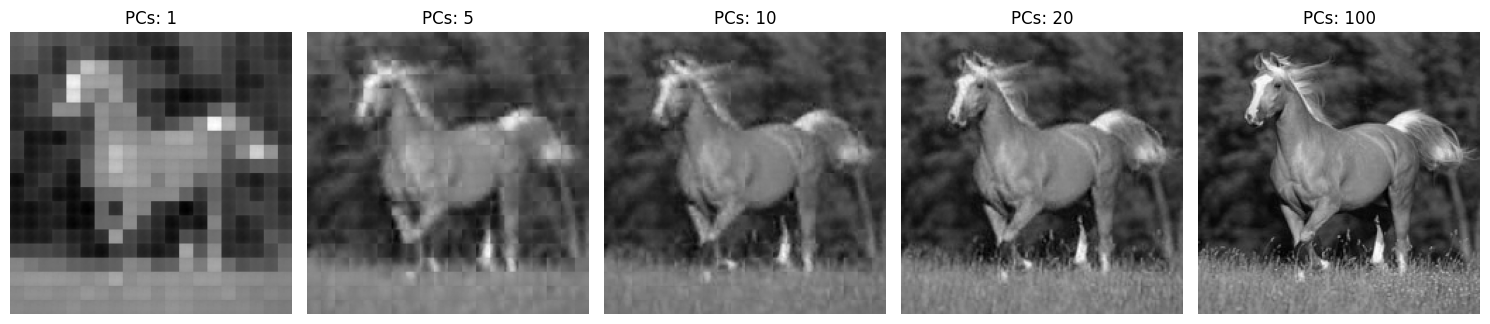

In [53]:
#@title { vertical-output: true}
def PCA_Image(features, image, n_components):
    # IMPLEMENT HERE
    # Step 1: Centering
    X = features - np.mean(features, axis=0)
    print('X shape:', X.shape)

    # Step 2: Covariance matrix from scratch
    cov = (X.T @ X) / (X.shape[0] - 1)

    # Step 3: Eigen values/vectors
    eig_values, eig_vectors = np.linalg.eigh(cov)

    # Step 4: Sort by eigenvalue (ascending order)
    idx = np.argsort(eig_values)
    eig_values = eig_values[idx]
    eig_vectors = eig_vectors[:, idx]

    # Projection
    Z = X @ eig_vectors

    num = 1
    plt.figure(figsize=(15, 5))
    for component in n_components:
        mu = np.mean(features, axis=0)
        num_eig, num_features = eig_vectors.shape

        # IMPLEMENT HERE: 상위 component개의 주성분으로 복원
        T = X @ eig_vectors[:, -component:]
        E = eig_vectors[:, -component:]
        R = (T @ E.T) + mu

        # Reconstruct image
        pixel_block = 10
        im_height, im_width = 200, 200
        reconstructed_image = np.zeros((im_height, im_width))
        x_idx = 0
        for i in range(0, im_height, pixel_block):
            for j in range(0, im_width, pixel_block):
                end_row = i + pixel_block
                end_column = j + pixel_block
                reconstructed_image[end_row - pixel_block:end_row, end_column - pixel_block:end_column] = np.reshape(R[x_idx], (10, 10))
                x_idx += 1

        ax = plt.subplot(1, len(n_components), num)
        ax.axis('off')
        num += 1
        plt.imshow(np.flipud(reconstructed_image), cmap='gray', origin='lower')
        plt.title(f'PCs: {component}')

    plt.tight_layout()
    plt.show()

# Run PCA on image
n_components = [1, 5, 10, 20, 100]
features, image = LoadImage("/content/drive/MyDrive/Colab Notebooks/palomino_horse.png")
print(f"Features shape: {features.shape}")
PCA_Image(features, image, n_components)

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `pca_학번_이름.ipynb`, `pca_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---